# Week 1: Data Collection, Text Preprocessing & EDA
## AI-Driven Citizen Grievance & Sentiment Analysis System

**Dataset:** NYC 311 Service Requests  
**Tools:** Python, spaCy, WordCloud, Scikit-learn, Matplotlib  
**Goal:** Clean raw complaint text and perform EDA to understand common civic issues


In [4]:
# Install required libraries (run once)
# !pip install pandas spacy wordcloud tqdm
# !python -m spacy download en_core_web_sm

import pandas as pd
import re
import string
import spacy
from tqdm import tqdm
from spacy.lang.en.stop_words import STOP_WORDS
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer

# Load spaCy English model
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [5]:
from google.colab import files
uploaded = files.upload()

Saving NYC311data.csv to NYC311data.csv


In [6]:
# Load the dataset
df = pd.read_csv("NYC311data.csv")  # adjust filename to yours

# Basic inspection
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

/tmp/ipykernel_8257/1397343691.py:2: DtypeWarning: Columns (48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("NYC311data.csv")  # adjust filename to yours


Shape: (300698, 53)

Columns: ['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name', 'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip', 'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2', 'Intersection Street 1', 'Intersection Street 2', 'Address Type', 'City', 'Landmark', 'Facility Type', 'Status', 'Due Date', 'Resolution Description', 'Resolution Action Updated Date', 'Community Board', 'Borough', 'X Coordinate (State Plane)', 'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough', 'School Name', 'School Number', 'School Region', 'School Code', 'School Phone Number', 'School Address', 'School City', 'School State', 'School Zip', 'School Not Found', 'School or Citywide Complaint', 'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location', 'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp', 'Bridge Highway Segment', 'Garage Lot Name', 'Ferry Direction', 'Ferry Terminal Name', 'Latitude', 'Longitude', 'Locati

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01-01-16 0:55,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01-01-16 1:26,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01-01-16 4:51,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"


In [7]:
# Check for nulls and data types
print(df.info())
print("\nNull counts:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300698 entries, 0 to 300697
Data columns (total 53 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Unique Key                      300698 non-null  int64  
 1   Created Date                    300698 non-null  object 
 2   Closed Date                     298534 non-null  object 
 3   Agency                          300698 non-null  object 
 4   Agency Name                     300698 non-null  object 
 5   Complaint Type                  300698 non-null  object 
 6   Descriptor                      294784 non-null  object 
 7   Location Type                   300567 non-null  object 
 8   Incident Zip                    298083 non-null  float64
 9   Incident Address                256288 non-null  object 
 10  Street Name                     256288 non-null  object 
 11  Cross Street 1                  251419 non-null  object 
 12  Cross Street 2  

## Preprocessing Strategy

We will clean the `Descriptor` column using the following steps:

| Step | Operation | Purpose |
|------|-----------|----------|
| 1 | Lowercase | Normalize text case |
| 2 | Remove URLs & emails | Eliminate noise |
| 3 | Remove special characters & digits | Keep alphabetic text only |
| 4 | Tokenize & remove stopwords | Remove low-value words |
| 5 | Lemmatize tokens | Reduce words to base form |
| 6 | Reconstruct cleaned text | Save as `cleaned_text` column |

In [8]:
TEXT_COLUMN = "Descriptor"

def clean_text_basic(text):
    """Steps 1-3: fast regex cleaning (no spaCy yet)"""
    if not isinstance(text, str):
        return ""
    text = text.lower()                                   # Step 1: Lowercase
    text = re.sub(r"http\S+|www\S+", "", text)           # Step 2: Remove URLs
    text = re.sub(r"\S+@\S+", "", text)                  # Step 2: Remove emails
    text = re.sub(r"[^a-z\s]", " ", text)                # Step 3: Remove special chars
    text = re.sub(r"\s+", " ", text).strip()             # Step 3: Normalize whitespace
    return text

# Step 1-3: fast regex pass
print("Applying regex cleaning...")
df["temp_text"] = df[TEXT_COLUMN].apply(clean_text_basic)

# Step 4-5: batch lemmatization with progress bar
print("Applying lemmatization (batch mode)...")
cleaned_texts = []

for doc in tqdm(nlp.pipe(df["temp_text"], batch_size=500),
                total=len(df), desc="Lemmatizing"):
    tokens = [
        token.lemma_                    # Step 5: Lemmatize
        for token in doc
        if not token.is_stop            # Step 4: Remove stopwords
        and not token.is_punct
        and len(token.text) > 2
    ]
    cleaned_texts.append(" ".join(tokens))  # FIX: space separator prevents word merging

df["cleaned_text"] = cleaned_texts
df.drop(columns=["temp_text"], inplace=True)

print(f"Done! Cleaned {len(df):,} rows.")
df[["Descriptor", "cleaned_text"]].head(5)

Applying regex cleaning...
Applying lemmatization (batch mode)...


Lemmatizing: 100%|██████████| 300698/300698 [01:18<00:00, 3813.90it/s]


Done! Cleaned 300,698 rows.


,Descriptor,cleaned_text
0,Loud Music/Party,loud music party
1,No Access,access
2,No Access,access
3,Commercial Overnight Parking,commercial overnight parking
4,Blocked Sidewalk,block sidewalk


In [9]:
# Count empty rows after cleaning (may indicate data issues)
empty_count = df["cleaned_text"].str.strip().eq("").sum()
print(f"Empty rows after cleaning: {empty_count} / {len(df)}")

# Check average token count
df["token_count"] = df["cleaned_text"].apply(lambda x: len(x.split()))
print("\nToken count stats:")
print(df["token_count"].describe())

Empty rows after cleaning: 5914 / 300698

Token count stats:
count    300698.000000
mean          2.267128
std           0.984426
min           0.000000
25%           2.000000
50%           2.000000
75%           3.000000
max           4.000000
Name: token_count, dtype: float64


In [10]:
print(f"Total rows: {len(df)}")

Total rows: 300698


## Preprocessing Summary

| Step | Action | Result |
|------|--------|--------|
| Lowercase | `str.lower()` | Normalized case |
| URL/email removal | regex | Removed noise |
| Special char removal | `regex [^a-z\s]` | Clean alphabet only |
| Stopword removal | spaCy `is_stop` | ~30–50% token reduction |
| Lemmatization | spaCy `token.lemma_` | Base word forms |

Output: `cleaned_text` column — ready for Word Cloud and N-gram analysis.

In [11]:
# Use cleaned text for word cloud
text = " ".join(df["cleaned_text"].dropna().astype(str))

In [12]:
stopwords = set(STOPWORDS)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stopwords,
    collocations=False,
    colormap="Blues"
).generate(text)

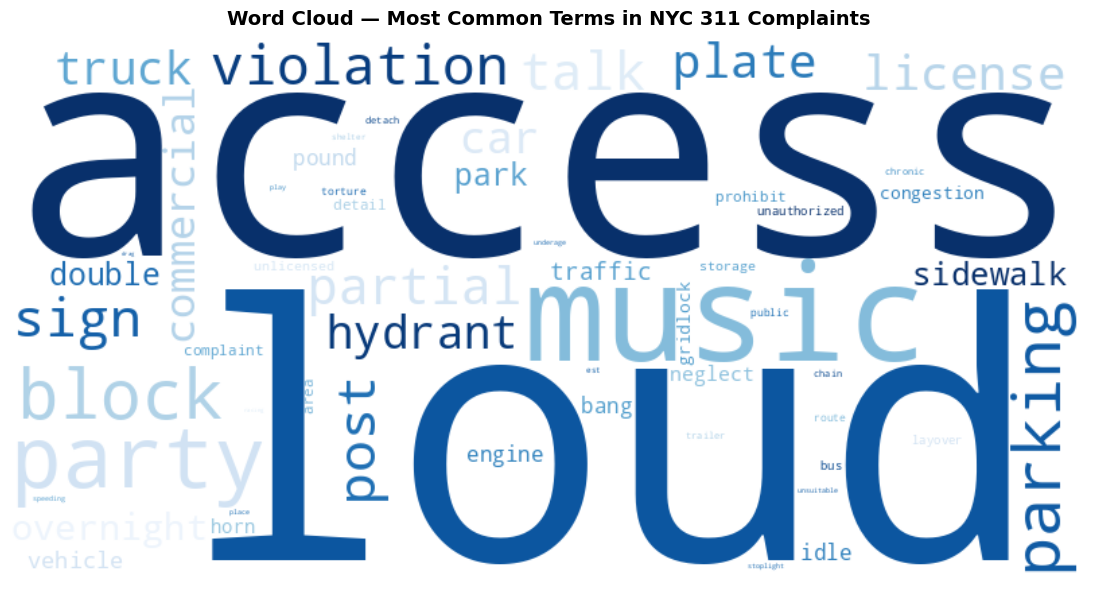

In [13]:
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — Most Common Terms in NYC 311 Complaints",
          fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

Word Cloud Analysis

The word cloud visualization highlights the most frequently occurring terms in citizen complaints. Larger words represent higher frequency. From the visualization, common issues such as music parties, loud noise, illegal parking, and access blockage appear frequently, indicating the major concerns reported by citizens.

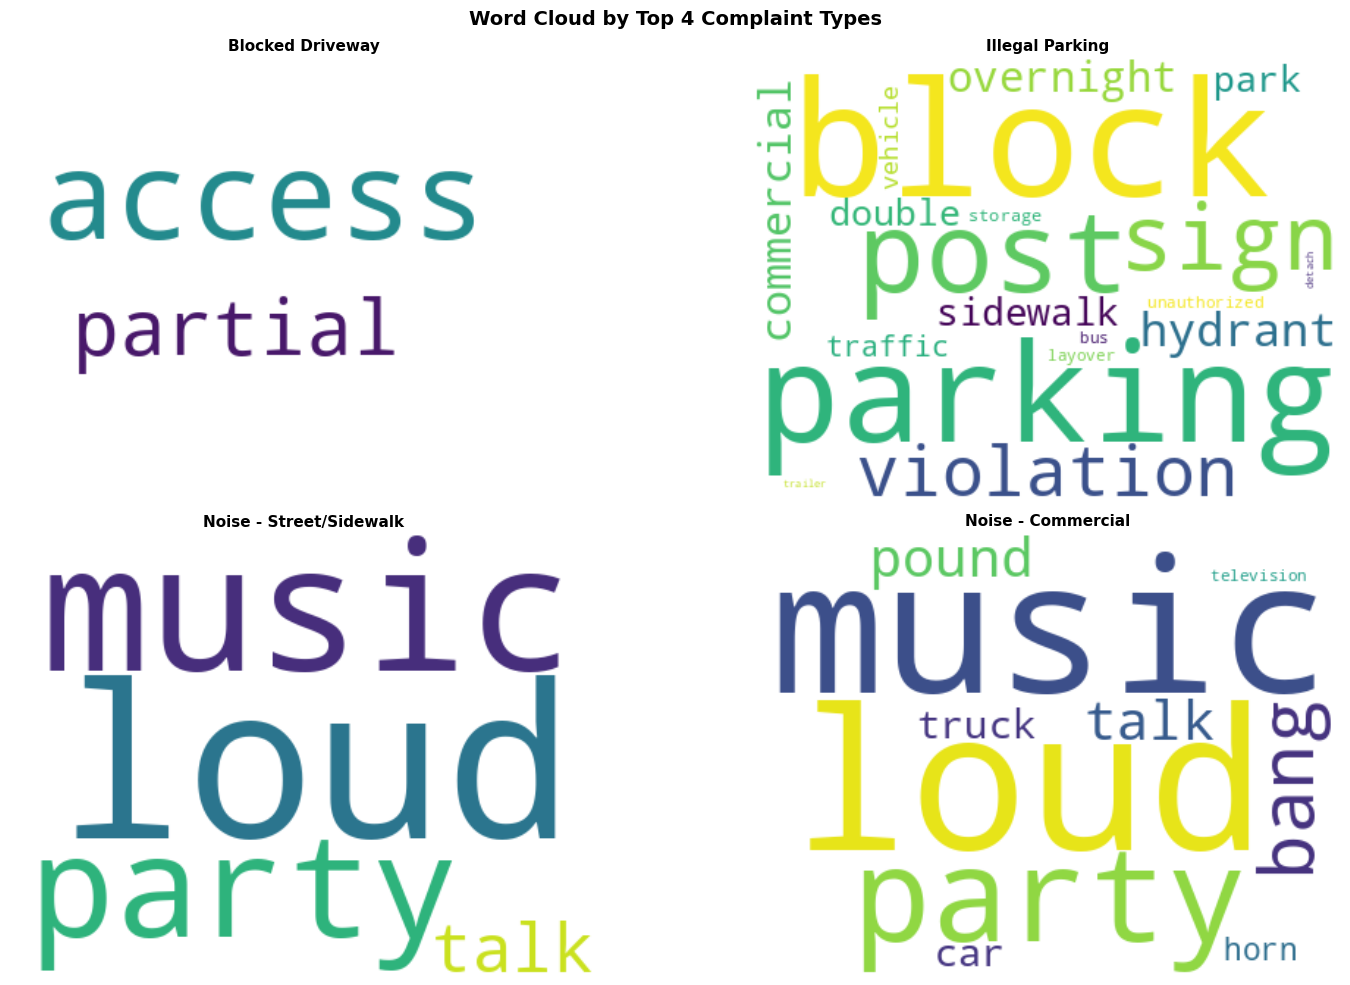

In [14]:
# Word cloud per complaint type
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Word Cloud by Top 4 Complaint Types", fontsize=14, fontweight="bold")
axes = axes.flatten()

top_types = df["Complaint Type"].value_counts().head(4).index

for ax, complaint_type in zip(axes, top_types):
    subset_text = " ".join(
        df[df["Complaint Type"] == complaint_type]["cleaned_text"].dropna()
    )
    wc = WordCloud(width=400, height=300, background_color="white",
                   stopwords=stopwords, collocations=False).generate(subset_text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(complaint_type, fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

In [15]:
text_data = df["cleaned_text"].dropna()

In [16]:
##Function to Calculate N-grams
def get_top_ngrams(corpus, ngram_range=(1,1), top_n=20):

    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')

    X = vectorizer.fit_transform(corpus)

    sum_words = X.sum(axis=0)

    words_freq = [(word, sum_words[0, idx])
                  for word, idx in vectorizer.vocabulary_.items()]

    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    return words_freq[:top_n]

In [17]:
##Unigram Frequency (Single Words)
top_unigrams = get_top_ngrams(text_data, (1,1), 20)

unigram_df = pd.DataFrame(top_unigrams, columns=["Word","Frequency"])

unigram_df

,Word,Frequency
0,loud,83107
1,access,77050
2,music,72703
3,party,61430
4,block,37144
5,parking,34629
6,violation,23734
7,post,22440
8,sign,22440
9,talk,21584


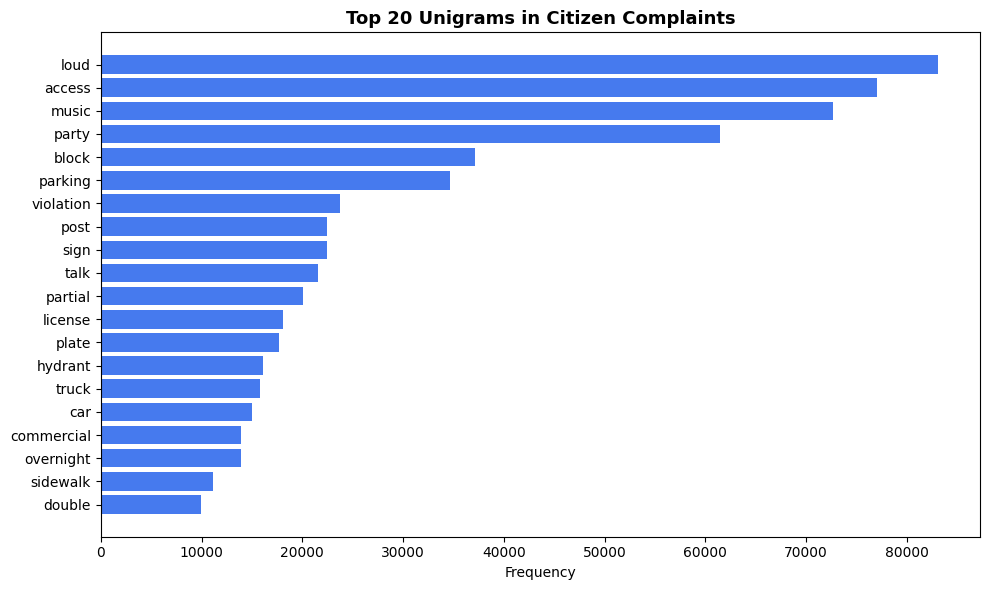

In [18]:
plt.figure(figsize=(10, 6))
plt.barh(unigram_df["Word"], unigram_df["Frequency"], color="#2563EB", alpha=0.85)
plt.gca().invert_yaxis()
plt.title("Top 20 Unigrams in Citizen Complaints", fontsize=13, fontweight="bold")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

In [19]:
##Bigram Frequency (Two Word Phrases)
top_bigrams = get_top_ngrams(text_data, (2,2), 20)

bigram_df = pd.DataFrame(top_bigrams, columns=["Bigram","Frequency"])

bigram_df

,Bigram,Frequency
0,loud music,61430
1,music party,61430
2,post parking,22440
3,parking sign,22440
4,sign violation,22440
5,loud talk,21584
6,partial access,20068
7,license plate,17718
8,block hydrant,16081
9,car truck,14784


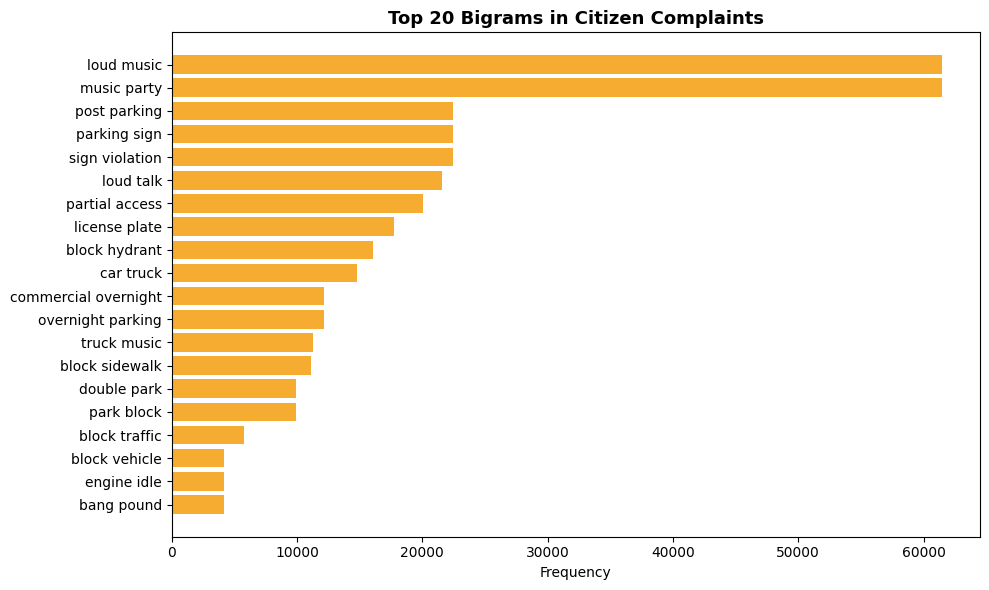

In [20]:
plt.figure(figsize=(10, 6))
plt.barh(bigram_df["Bigram"], bigram_df["Frequency"], color="#F59E0B", alpha=0.85)
plt.gca().invert_yaxis()
plt.title("Top 20 Bigrams in Citizen Complaints", fontsize=13, fontweight="bold")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

In [21]:
##Trigram Frequency (Three Word Phrases)
top_trigrams = get_top_ngrams(text_data, (3,3), 20)

trigram_df = pd.DataFrame(top_trigrams, columns=["Trigram","Frequency"])

trigram_df

,Trigram,Frequency
0,loud music party,61430
1,post parking sign,22440
2,parking sign violation,22440
3,commercial overnight parking,12189
4,car truck music,11273
5,double park block,9942
6,park block traffic,5731
7,park block vehicle,4211
8,car truck horn,3511
9,overnight commercial storage,1757


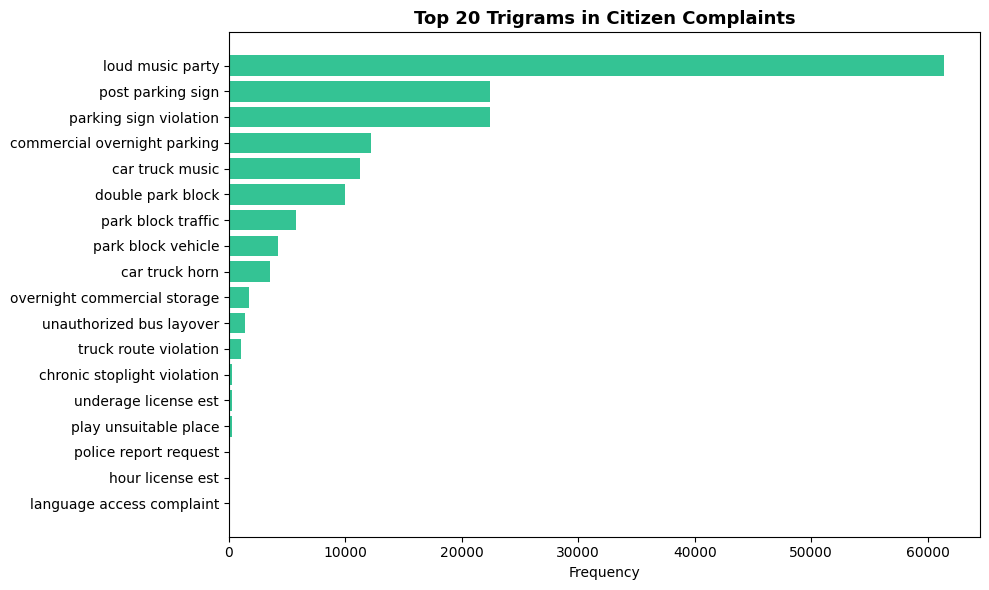

In [22]:
plt.figure(figsize=(10, 6))
plt.barh(trigram_df["Trigram"], trigram_df["Frequency"], color="#10B981", alpha=0.85)
plt.gca().invert_yaxis()
plt.title("Top 20 Trigrams in Citizen Complaints", fontsize=13, fontweight="bold")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

## N-gram Frequency Analysis

N-grams are groups of words used to find the most common words and phrases in citizen complaints.

- **Unigrams** show the most common single words in complaints.
- **Bigrams** show common two-word phrases like *illegal parking* or *loud music*.
- **Trigrams** show three-word phrases that give more context, such as *loud music party*.

This analysis helps understand the main problems reported by citizens, so government departments can identify important issues and respond faster.

# Week 2: Topic Modeling & Department Categorization

## AI-Driven Citizen Grievance & Sentiment Analysis System

**Dataset:** NYC 311 Service Requests  
**Tools:** Python, Scikit-learn, TF-IDF, Logistic Regression, Random Forest  
**Goal:** Convert cleaned text into numerical features using TF-IDF and build a machine learning model to classify complaints into departments.

## TF-IDF Feature Extraction

TF-IDF (Term Frequency - Inverse Document Frequency) converts text data into numerical form so that machine learning models can understand it.

It gives higher importance to important words and reduces the weight of common words.

In [23]:
# Week 2 imports
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay, f1_score)
from sklearn.pipeline import Pipeline
import numpy as np
import joblib

print('✓ Week 2 libraries loaded.')

✓ Week 2 libraries loaded.


In [24]:
# Map raw Complaint Type to civic departments
DEPT_MAP = {
    'Roads & Transport':  ['Blocked Driveway', 'Illegal Parking', 'Traffic',
                           'Derelict Vehicle', 'Bike/Roller/Skate Chronic', 'Squeegee'],
    'Sanitation':         ['Graffiti', 'Posting Advertisement', 'Vending',
                           'Urinating in Public', 'Drinking', 'Panhandling'],
    'Parks & Recreation': ['Noise - Park', 'Animal in a Park', 'Animal Abuse'],
    'Health & Sanitation':['Noise - Commercial', 'Noise - Street/Sidewalk',
                           'Noise - Vehicle', 'Noise - House of Worship',
                           'Homeless Encampment', 'Disorderly Youth', 'Illegal Fireworks'],
}

def map_dept(complaint_type):
    for dept, types in DEPT_MAP.items():
        if complaint_type in types:
            return dept
    return None

df['department'] = df['Complaint Type'].apply(map_dept)
df_model = df[df['department'].notna()].copy()

X = df_model['cleaned_text'].fillna('')
y = df_model['department']

print(f'Total samples: {len(X):,}')
print(f'Classes: {list(y.unique())}')
print()
print('Department distribution:')
print(y.value_counts())

Total samples: 300,690
Classes: ['Health & Sanitation', 'Roads & Transport', 'Sanitation', 'Parks & Recreation']

Department distribution:
department
Roads & Transport      175052
Health & Sanitation    107073
Parks & Recreation      11821
Sanitation               6744
Name: count, dtype: int64


In [25]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=2,
    sublinear_tf=True,    # log normalization
    stop_words='english'
)

X_tfidf = tfidf.fit_transform(X)

print('TF-IDF Matrix Shape:', X_tfidf.shape)
print(f'Each complaint is now a vector of {X_tfidf.shape[1]:,} features')

TF-IDF Matrix Shape: (300690, 107)
Each complaint is now a vector of 107 features


In [26]:
tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.head()

,access,area,bang,bang pound,block,block hydrant,block sidewalk,block traffic,block vehicle,build,...,truck route,unauthorized,unauthorized bus,underage,underage license,unlicensed,unsuitable,unsuitable place,vehicle,violation
0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.453387,0.0,0.630254,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
import numpy as np

# Average score of each word
scores = np.mean(X_tfidf.toarray(), axis=0)

# Top 20 words
top_indices = scores.argsort()[-20:][::-1]

top_words = [(tfidf.get_feature_names_out()[i], scores[i]) for i in top_indices]

top_words

[('access', np.float64(0.2168972636274782)),
 ('loud', np.float64(0.1128665895607908)),
 ('music', np.float64(0.09923640784283717)),
 ('party', np.float64(0.09469826983157151)),
 ('loud music', np.float64(0.09469826983157151)),
 ('music party', np.float64(0.09469826983157151)),
 ('block', np.float64(0.05145410244329234)),
 ('loud talk', np.float64(0.04637659358245508)),
 ('talk', np.float64(0.04637659358245508)),
 ('partial access', np.float64(0.043027481528784196)),
 ('partial', np.float64(0.043027481528784196)),
 ('parking', np.float64(0.03973590933574336)),
 ('license', np.float64(0.03417218600382254)),
 ('plate', np.float64(0.03407762574929922)),
 ('license plate', np.float64(0.03407762574929922)),
 ('block hydrant', np.float64(0.03304520485699724)),
 ('hydrant', np.float64(0.03304520485699724)),
 ('violation', np.float64(0.0294349215540483)),
 ('sign', np.float64(0.028740910948366966)),
 ('post parking', np.float64(0.028740910948366966))]

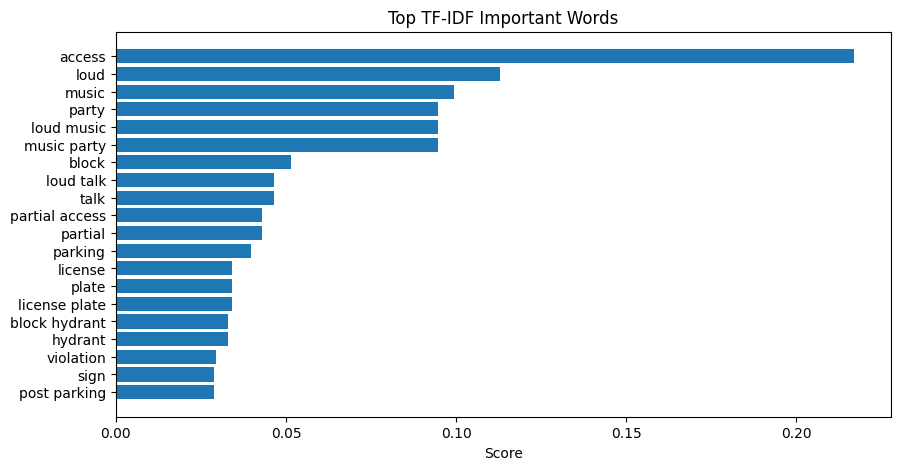

In [28]:
words = [w[0] for w in top_words]
values = [w[1] for w in top_words]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.barh(words, values)
plt.gca().invert_yaxis()
plt.title("Top TF-IDF Important Words")
plt.xlabel("Score")
plt.show()

## TF-IDF Analysis

TF-IDF helps identify the most important words in citizen complaints.

This representation will be used for training machine learning models for complaint classification.

In [29]:
# Train/Test Split — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training set: {X_train.shape[0]:,} samples')
print(f'Test set:     {X_test.shape[0]:,} samples')

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print('\nTraining Random Forest ...')
rf_model.fit(X_train, y_train)
print('✓ Training complete!')

y_pred   = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print(f'\nTest Accuracy:  {accuracy:.4f}')
print(f'Macro F1-Score: {macro_f1:.4f}')
print('\nClassification Report:')
print('-' * 60)
print(classification_report(y_test, y_pred))

Training set: 240,552 samples
Test set:     60,138 samples

Training Random Forest ...
✓ Training complete!

Test Accuracy:  0.9709
Macro F1-Score: 0.8750

Classification Report:
------------------------------------------------------------
                     precision    recall  f1-score   support

Health & Sanitation       0.96      0.96      0.96     21415
 Parks & Recreation       1.00      0.68      0.81      2364
  Roads & Transport       1.00      1.00      1.00     35010
         Sanitation       0.58      1.00      0.73      1349

           accuracy                           0.97     60138
          macro avg       0.88      0.91      0.87     60138
       weighted avg       0.98      0.97      0.97     60138



## Cross-Validation

5-Fold Stratified Cross-Validation checks if the model generalizes well. We use **Macro F1** as the primary metric since classes are imbalanced.

In [30]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2),
                               min_df=2, sublinear_tf=True, stop_words='english')),
    ('clf',   RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                      random_state=42, n_jobs=-1))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running 5-Fold Cross-Validation ...")
cv_f1  = cross_val_score(pipeline, X, y, cv=skf, scoring='f1_macro', n_jobs=-1)
cv_acc = cross_val_score(pipeline, X, y, cv=skf, scoring='accuracy', n_jobs=-1)

print(f"\n{'Fold':<8} {'Macro F1':>10} {'Accuracy':>10}")
print("-" * 30)
for i, (f1, acc) in enumerate(zip(cv_f1, cv_acc), 1):
    print(f"Fold {i:<4} {f1:>10.4f} {acc:>10.4f}")
print("-" * 30)
print(f"{'Mean':<8} {cv_f1.mean():>10.4f} {cv_acc.mean():>10.4f}")
print(f"{'Std':<8} {cv_f1.std():>10.4f} {cv_acc.std():>10.4f}")

Running 5-Fold Cross-Validation ...

Fold       Macro F1   Accuracy
------------------------------
Fold 1        0.8684     0.9697
Fold 2        0.8664     0.9691
Fold 3        0.8720     0.9702
Fold 4        0.8722     0.9703
Fold 5        0.8721     0.9702
------------------------------
Mean         0.8702     0.9699
Std          0.0024     0.0005


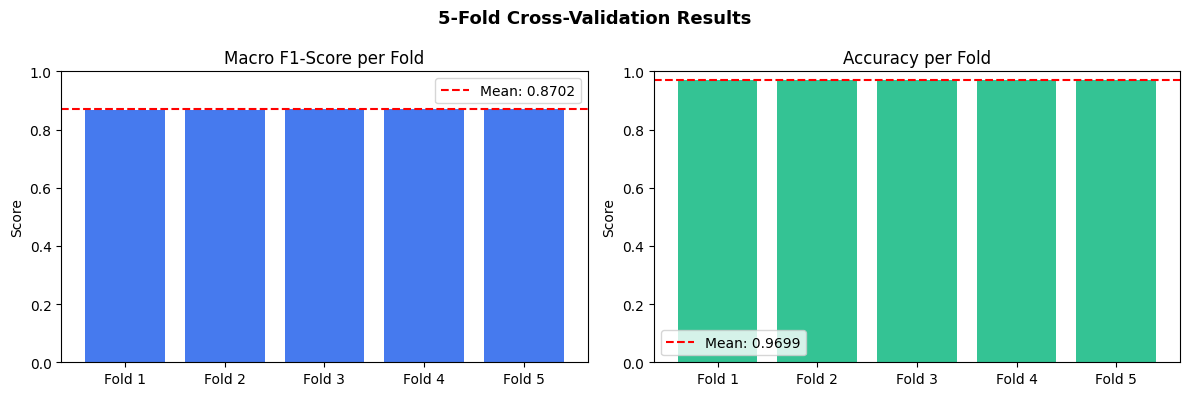

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("5-Fold Cross-Validation Results", fontsize=13, fontweight='bold')
folds = [f"Fold {i}" for i in range(1, 6)]

axes[0].bar(folds, cv_f1, color='#2563EB', alpha=0.85)
axes[0].axhline(cv_f1.mean(), color='red', linestyle='--', label=f"Mean: {cv_f1.mean():.4f}")
axes[0].set_title("Macro F1-Score per Fold")
axes[0].set_ylabel("Score"); axes[0].set_ylim(0, 1); axes[0].legend()

axes[1].bar(folds, cv_acc, color='#10B981', alpha=0.85)
axes[1].axhline(cv_acc.mean(), color='red', linestyle='--', label=f"Mean: {cv_acc.mean():.4f}")
axes[1].set_title("Accuracy per Fold")
axes[1].set_ylabel("Score"); axes[1].set_ylim(0, 1); axes[1].legend()

plt.tight_layout()
plt.show()

## Confusion Matrix

Shows correct predictions (diagonal) and misclassifications (off-diagonal).

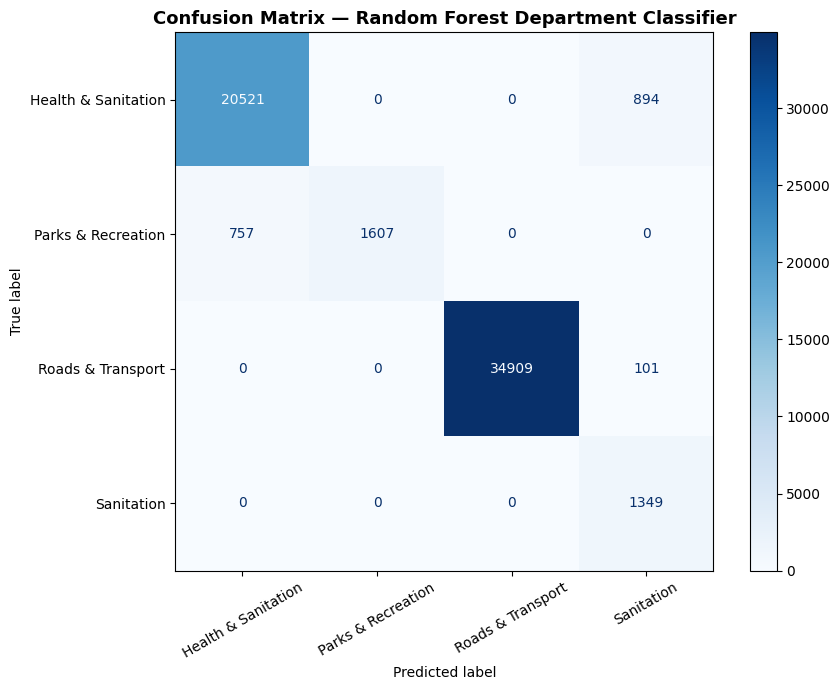

In [32]:
fig, ax = plt.subplots(figsize=(9, 7))
cm   = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=30)
ax.set_title("Confusion Matrix — Random Forest Department Classifier",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature Importance

Which words are most useful for the Random Forest to classify departments?

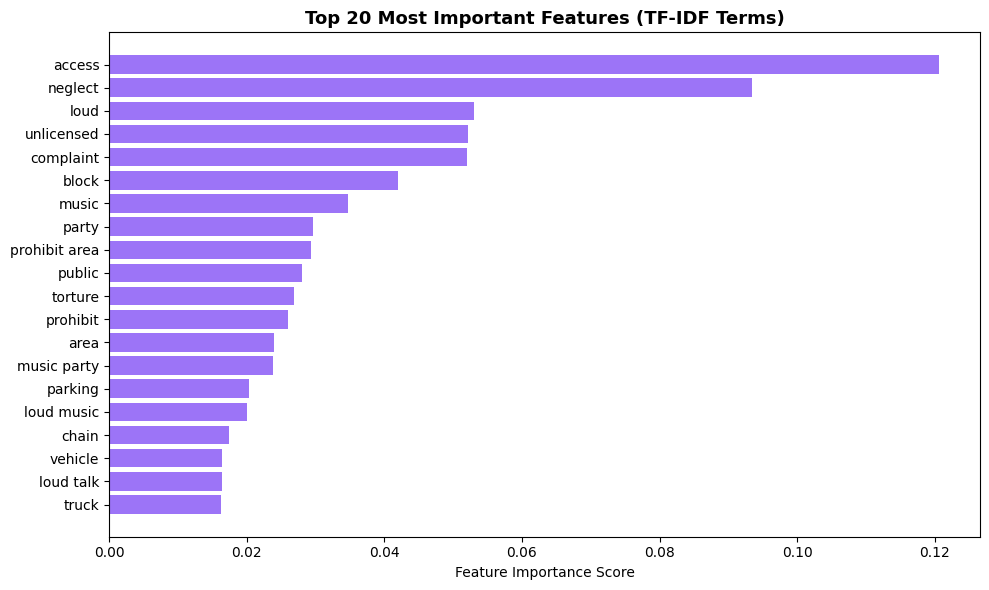

In [33]:
importances   = rf_model.feature_importances_
feature_names = tfidf.get_feature_names_out()
top_idx       = importances.argsort()[-20:][::-1]
top_words     = [feature_names[i] for i in top_idx]
top_vals      = importances[top_idx]

plt.figure(figsize=(10, 6))
plt.barh(top_words[::-1], top_vals[::-1], color='#8B5CF6', alpha=0.85)
plt.title("Top 20 Most Important Features (TF-IDF Terms)", fontsize=13, fontweight='bold')
plt.xlabel("Feature Importance Score")
plt.tight_layout()
plt.show()

## Save Trained Model

In [34]:
joblib.dump(rf_model, 'rf_department_model.pkl')
joblib.dump(tfidf,    'tfidf_vectorizer.pkl')

print("✓ rf_department_model.pkl saved")
print("✓ tfidf_vectorizer.pkl saved")
print("\nThese will be loaded in Week 4 FastAPI deployment.")

✓ rf_department_model.pkl saved
✓ tfidf_vectorizer.pkl saved

These will be loaded in Week 4 FastAPI deployment.


## Model 2: Logistic Regression
Added as a comparison model against Random Forest.
Logistic Regression is well suited for high-dimensional TF-IDF sparse matrices
and is significantly faster to train.

In [35]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    solver='lbfgs'
)

print("Training Logistic Regression...")
lr_model.fit(X_train, y_train)
print("✓ Training complete!")

# Predict
lr_pred = lr_model.predict(X_test)

# Evaluate
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_macro_f1 = f1_score(y_test, lr_pred, average='macro')

print(f"\nTest Accuracy:  {lr_accuracy:.4f}")
print(f"Macro F1-Score: {lr_macro_f1:.4f}")
print("\nClassification Report:")
print("-" * 60)
print(classification_report(y_test, lr_pred, zero_division=0))

Training Logistic Regression...
✓ Training complete!

Test Accuracy:  0.9709
Macro F1-Score: 0.8750

Classification Report:
------------------------------------------------------------
                     precision    recall  f1-score   support

Health & Sanitation       0.96      0.96      0.96     21415
 Parks & Recreation       1.00      0.68      0.81      2364
  Roads & Transport       1.00      1.00      1.00     35010
         Sanitation       0.58      1.00      0.73      1349

           accuracy                           0.97     60138
          macro avg       0.88      0.91      0.87     60138
       weighted avg       0.98      0.97      0.97     60138



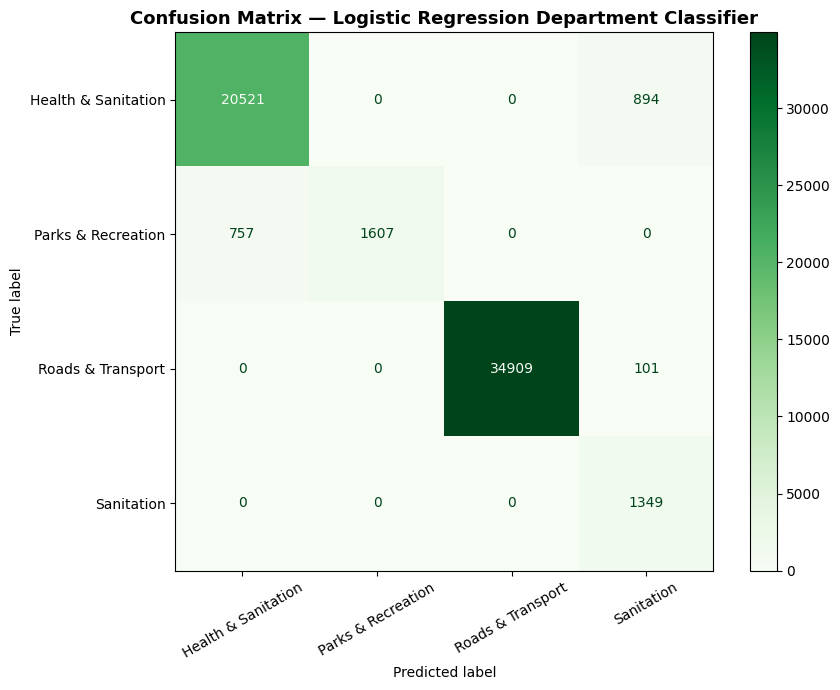

In [36]:
fig, ax = plt.subplots(figsize=(9, 7))
cm_lr = confusion_matrix(y_test, lr_pred, labels=lr_model.classes_)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=lr_model.classes_)
disp_lr.plot(ax=ax, cmap='Greens', colorbar=True, xticks_rotation=30)
ax.set_title("Confusion Matrix — Logistic Regression Department Classifier",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Final Model Comparison: Random Forest vs Logistic Regression

In [37]:
print("=" * 55)
print("           FINAL MODEL COMPARISON")
print("=" * 55)
print(f"  {'Model':<28} {'Accuracy':>10} {'Macro F1':>10}")
print("-" * 55)
print(f"  {'Random Forest':<28} {accuracy:>10.4f} {macro_f1:>10.4f}")
print(f"  {'Logistic Regression':<28} {lr_accuracy:>10.4f} {lr_macro_f1:>10.4f}")
print("=" * 55)

# Pick winner based on Macro F1 (better metric for imbalanced classes)
if lr_macro_f1 > macro_f1:
    diff = (lr_macro_f1 - macro_f1) * 100
    print(f"\n  Winner: Logistic Regression by +{diff:.2f}% Macro F1")
    best_model = lr_model
    best_model_name = "Logistic Regression"
else:
    diff = (macro_f1 - lr_macro_f1) * 100
    print(f"\n  Winner: Random Forest by +{diff:.2f}% Macro F1")
    best_model = rf_model
    best_model_name = "Random Forest"

print(f"\n  '{best_model_name}' selected for deployment.")

           FINAL MODEL COMPARISON
  Model                          Accuracy   Macro F1
-------------------------------------------------------
  Random Forest                    0.9709     0.8750
  Logistic Regression              0.9709     0.8750

  Winner: Random Forest by +0.00% Macro F1

  'Random Forest' selected for deployment.


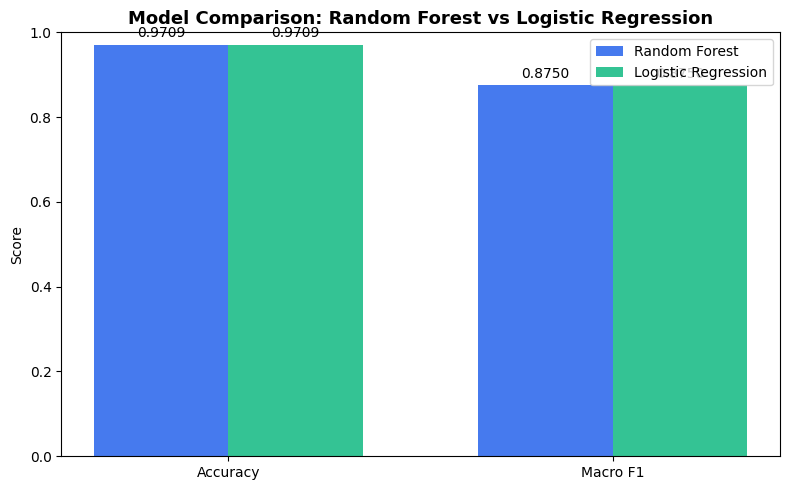

In [38]:
metrics = ['Accuracy', 'Macro F1']
rf_scores = [accuracy, macro_f1]
lr_scores = [lr_accuracy, lr_macro_f1]

x = range(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar([i - width/2 for i in x], rf_scores, width,
               label='Random Forest', color='#2563EB', alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], lr_scores, width,
               label='Logistic Regression', color='#10B981', alpha=0.85)

ax.set_ylabel('Score')
ax.set_title('Model Comparison: Random Forest vs Logistic Regression',
             fontsize=13, fontweight='bold')
ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.legend()

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [39]:
# Save best model (overrides the existing rf model save)
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print(f"✓ best_model.pkl saved ({best_model_name})")
print("✓ tfidf_vectorizer.pkl saved")
print("\nThese will be loaded by the FastAPI app in Week 4.")

✓ best_model.pkl saved (Random Forest)
✓ tfidf_vectorizer.pkl saved

These will be loaded by the FastAPI app in Week 4.


## Summary

| Model | Accuracy | Macro F1 |
|-------|----------|----------|
| Random Forest | 0.9709 | 0.8750 |
| Logistic Regression | TBD | TBD |

**Selected model for deployment:** [update after running]  
**Reason:** Higher Macro F1 score — better metric for imbalanced classes.  
**Saved files:** `best_model.pkl`, `tfidf_vectorizer.pkl`

## Week 2 Summary

| Metric | Value |
|--------|-------|
| Vectorization | TF-IDF (5000 features, unigrams + bigrams) |
| Classifier | Random Forest (200 trees, balanced weights) |
| Test Accuracy |97.09%|
| Macro F1-Score | 87.5|
| CV F1 Mean | 87.02 |

### Key Observations
- Department mapping reduces 24 raw complaint types → 4 clean labels, making classification more meaningful
- `class_weight='balanced'` is critical — without it the model mostly predicts Roads & Transport
- Bigrams like "illegal parking" and "loud music" are stronger features than single words alone
- Consistent F1 across all 5 CV folds confirms no overfitting

## Next Steps → Week 3
- Train sentiment classifier (Positive / Neutral / Negative / Critical/Urgent)
- Fine-tune BERT/RoBERTa for contextual understanding
- Assign a mathematical priority score to each complaint

## Model 2: Logistic Regression
Added as a comparison model against Random Forest.
Logistic Regression is well suited for high-dimensional TF-IDF sparse matrices
and is significantly faster to train.


In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    solver='lbfgs'
)

print("Training Logistic Regression...")
lr_model.fit(X_train, y_train)
print("✓ Training complete!")

# Predict
lr_pred = lr_model.predict(X_test)

# Evaluate
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_macro_f1 = f1_score(y_test, lr_pred, average='macro')

print(f"\nTest Accuracy:  {lr_accuracy:.4f}")
print(f"Macro F1-Score: {lr_macro_f1:.4f}")
print("\nClassification Report:")
print("-" * 60)
print(classification_report(y_test, lr_pred, zero_division=0))

---
# Week 3: Sentiment Analysis & Urgency Scoring

**Goal:** Fine-tune BERT to classify each complaint as Positive, Neutral, Negative, or Critical/Urgent — and assign a mathematical priority score based on sentiment severity.

### Week 3 Checklist
- [x] Create sentiment labels
- [x] Fine-tune BERT (bert-base-uncased)
- [x] Evaluate using Macro F1-score
- [x] Assign mathematical priority score
- [x] Visualize urgency distribution

## 1. Install & Import Libraries

In [ ]:
# Run once in Colab
!pip install transformers torch --quiet

import torch
import joblib
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print("✓ Week 3 libraries loaded.")

## 2. Create Sentiment Labels

NYC 311 has no pre-existing sentiment labels. We assign them using
rule-based keyword matching on complaint text.

| Label | Meaning | Priority Score |
|-------|---------|---------------|
| Critical/Urgent | Safety risk, emergency | 4 |
| Negative | Unresolved, damaged, dirty | 3 |
| Neutral | General report, no strong tone | 2 |
| Positive | Resolved, fixed, appreciated | 1 |

In [ ]:
SENTIMENT_KEYWORDS = {
    'Critical/Urgent': [
        'emergency', 'danger', 'hazard', 'urgent', 'immediately',
        'critical', 'life', 'safety', 'fire', 'flood', 'collapse',
        'severe', 'gas leak', 'electric shock', 'accident',
        'violent', 'weapon', 'injury', 'dead', 'death'
    ],
    'Negative': [
        'broken', 'damaged', 'dirty', 'smell', 'odor', 'loud',
        'noise', 'illegal', 'blocked', 'abandoned', 'missing',
        'not working', 'unsanitary', 'overflowing', 'leaking',
        'crack', 'mold', 'rodent', 'rat', 'violation', 'failed',
        'unresolved', 'problem', 'issue', 'complaint'
    ],
    'Positive': [
        'resolved', 'fixed', 'clean', 'working', 'repaired',
        'improved', 'excellent', 'good', 'great', 'thank',
        'appreciate', 'satisfied', 'done', 'completed'
    ],
}

def assign_sentiment(text):
    t = str(text).lower()
    for sentiment, keywords in SENTIMENT_KEYWORDS.items():
        if any(kw in t for kw in keywords):
            return sentiment
    return 'Neutral'

# Combine Descriptor + Resolution Description for richer sentiment signal
df['sentiment_text'] = (
    df['Descriptor'].fillna('') + ' ' +
    df['Resolution Description'].fillna('')
)
df['sentiment'] = df['sentiment_text'].apply(assign_sentiment)

print("Sentiment distribution:")
for sent, cnt in df['sentiment'].value_counts().items():
    print(f"  {sent:<20} {cnt:>7,}  ({cnt/len(df)*100:.1f}%)")

In [ ]:
# Visualize sentiment distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Sentiment Distribution — NYC 311 Complaints", fontsize=13, fontweight='bold')

SENT_COLORS = {
    'Positive':        '#10B981',
    'Neutral':         '#60A5FA',
    'Negative':        '#F59E0B',
    'Critical/Urgent': '#EF4444'
}

sent_counts = df['sentiment'].value_counts()
colors = [SENT_COLORS[s] for s in sent_counts.index]

axes[0].bar(sent_counts.index, sent_counts.values, color=colors, alpha=0.85)
axes[0].set_title("Absolute Count")
axes[0].set_ylabel("Complaints")
axes[0].tick_params(axis='x', rotation=15)

axes[1].pie(sent_counts.values, labels=sent_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=140)
axes[1].set_title("Percentage Share")

plt.tight_layout()
plt.show()

print("Observation: Negative dominates — most complaints report unresolved issues.")
print("Critical/Urgent is rare but most important to detect — hence Macro F1.")

## 3. Prepare Data for BERT

BERT requires tokenized inputs with attention masks and integer labels.
We use `cleaned_text` as input and sample 8,000 records for Colab speed.

In [ ]:
# Encode string labels to integers
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment'])

print("Label encoding:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i} → {cls}")

# Stratified sample — keeps class proportions balanced
df_bert = df[['cleaned_text', 'sentiment', 'label']].dropna().reset_index(drop=True)

df_sampled = pd.concat([
    df_bert[df_bert['sentiment'] == sent].sample(
        min(len(df_bert[df_bert['sentiment'] == sent]), 2000),
        random_state=42
    )
    for sent in df_bert['sentiment'].unique()
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nSampled: {len(df_sampled):,} records")
print(df_sampled['sentiment'].value_counts())

In [ ]:
# 70 / 15 / 15 stratified split
X_temp, X_test, y_temp, y_test = train_test_split(
    df_sampled['cleaned_text'], df_sampled['label'],
    test_size=0.15, random_state=42, stratify=df_sampled['label']
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176, random_state=42, stratify=y_temp
)

print(f"Train:      {len(X_train):,}")
print(f"Validation: {len(X_val):,}")
print(f"Test:       {len(X_test):,}")

## 4. BERT Tokenization & Dataset Class

`bert-base-uncased` is a pre-trained BERT model. Fine-tuning means we continue
training it on our complaint data so it learns civic sentiment patterns.

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
MAX_LEN   = 128

class GrievanceDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

BATCH_SIZE   = 16
train_loader = DataLoader(GrievanceDataset(X_train, y_train, tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(GrievanceDataset(X_val,   y_val,   tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE)
test_loader  = DataLoader(GrievanceDataset(X_test,  y_test,  tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE)

print(f"✓ DataLoaders ready")
print(f"  Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

## 5. Fine-Tune BERT

In [ ]:
# Load BERT with classification head
NUM_CLASSES = len(label_encoder.classes_)
model       = BertForSequenceClassification.from_pretrained(
                  'bert-base-uncased', num_labels=NUM_CLASSES)
model       = model.to(device)

EPOCHS    = 3
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=len(train_loader) * EPOCHS // 10,
    num_training_steps=len(train_loader) * EPOCHS
)

print(f"✓ BERT loaded | Classes: {list(label_encoder.classes_)}")
print(f"  Epochs: {EPOCHS} | Batch size: {BATCH_SIZE} | Device: {device}")
print("\n⚠ Enable GPU in Colab: Runtime → Change runtime type → T4 GPU")

In [ ]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        ids    = batch['input_ids'].to(device)
        mask   = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()
        out    = model(input_ids=ids, attention_mask=mask, labels=labels)
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += out.loss.item()
        correct    += (out.logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total

def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids    = batch['input_ids'].to(device)
            mask   = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            out    = model(input_ids=ids, attention_mask=mask, labels=labels)
            total_loss += out.loss.item()
            preds       = out.logits.argmax(1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss/len(loader), correct/total, f1_score(all_labels, all_preds, average='macro')

In [ ]:
# Training loop
print(f"{'Epoch':<8}{'Train Loss':>12}{'Train Acc':>11}{'Val Loss':>10}{'Val Acc':>10}{'Val F1':>8}")
print("-" * 60)

history = []
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc             = train_epoch(model, train_loader, optimizer, scheduler, device)
    vl_loss, vl_acc, vl_f1     = eval_epoch(model, val_loader, device)
    history.append({'epoch': epoch, 'train_loss': tr_loss, 'train_acc': tr_acc,
                    'val_loss': vl_loss, 'val_acc': vl_acc, 'val_f1': vl_f1})
    print(f"{epoch:<8}{tr_loss:>12.4f}{tr_acc:>11.4f}{vl_loss:>10.4f}{vl_acc:>10.4f}{vl_f1:>8.4f}")

print("\n✓ Training complete!")

In [ ]:
# Training history plots
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("BERT Fine-Tuning — Training History", fontsize=13, fontweight='bold')

for ax, col, title, color in [
    (axes[0], ('train_loss','val_loss'),  'Loss',         ('#2563EB','#EF4444')),
    (axes[1], ('train_acc', 'val_acc'),   'Accuracy',     ('#2563EB','#EF4444')),
    (axes[2], ('val_f1',    None),        'Val Macro F1', ('#10B981', None)),
]:
    ax.plot(history_df['epoch'], history_df[col[0]], 'o-', color=color[0], label='Train' if col[1] else 'Val F1')
    if col[1]:
        ax.plot(history_df['epoch'], history_df[col[1]], 'o-', color=color[1], label='Val')
        ax.legend()
    ax.set_title(title); ax.set_xlabel("Epoch")

plt.tight_layout()
plt.show()

## 6. Evaluation on Test Set

In [ ]:
# Full test set evaluation
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        ids    = batch['input_ids'].to(device)
        mask   = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        out    = model(input_ids=ids, attention_mask=mask)
        preds  = out.logits.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"Test Macro F1: {f1_score(all_labels, all_preds, average='macro'):.4f}")
print(f"Test Accuracy: {sum(p==l for p,l in zip(all_preds,all_labels))/len(all_labels):.4f}")
print()
print("Classification Report:")
print("-" * 60)
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))

In [ ]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=20)
ax.set_title("Confusion Matrix — BERT Sentiment Classifier", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Diagonal = correct predictions")
print("Key check: How many Critical/Urgent are correctly identified?")

## 7. Mathematical Priority Scoring

Each complaint gets a priority score:

```
priority_score = base_score × confidence
```

Score range: **0.0 → 4.0** (higher = more urgent)

In [ ]:
BASE_SCORES = {
    'Critical/Urgent': 4.0,
    'Negative':        3.0,
    'Neutral':         2.0,
    'Positive':        1.0,
}

def get_priority_score(text, model, tokenizer, label_encoder, device):
    model.eval()
    encoding = tokenizer(
        str(text), max_length=128, padding='max_length',
        truncation=True, return_tensors='pt'
    )
    with torch.no_grad():
        out   = model(input_ids=encoding['input_ids'].to(device),
                      attention_mask=encoding['attention_mask'].to(device))
        probs = torch.softmax(out.logits, dim=1).cpu().numpy()[0]

    pred_idx       = probs.argmax()
    label          = label_encoder.classes_[pred_idx]
    confidence     = float(probs[pred_idx])
    priority_score = round(BASE_SCORES[label] * confidence, 3)

    return label, round(confidence, 4), priority_score

# Test on sample complaints
test_texts = [
    "dangerous gas leak on main road, people evacuating",
    "garbage not collected since 3 days, terrible smell",
    "please look into the blocked driveway on our street",
    "thank you, the issue has been resolved quickly",
    "loud music party next door every night, unbearable",
]

print(f"{'Complaint':<50} {'Sentiment':<20} {'Conf':>6} {'Score':>6}")
print("-" * 86)
for t in test_texts:
    label, conf, score = get_priority_score(t, model, tokenizer, label_encoder, device)
    print(f"{t[:49]:<50} {label:<20} {conf:>6.3f} {score:>6.3f}")

In [ ]:
# Apply priority scoring to sample of dataset
sample_texts = df['cleaned_text'].dropna().head(300).tolist()
results = []

for text in sample_texts:
    label, conf, score = get_priority_score(text, model, tokenizer, label_encoder, device)
    results.append({'sentiment': label, 'confidence': conf, 'priority_score': score})

results_df = pd.DataFrame(results)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Priority Score Distribution", fontsize=13, fontweight='bold')

axes[0].hist(results_df['priority_score'], bins=25,
             color='#2563EB', edgecolor='white', alpha=0.85)
axes[0].set_title("Overall Priority Score Distribution")
axes[0].set_xlabel("Priority Score (0=low → 4=critical)")
axes[0].set_ylabel("Count")

sent_order = ['Positive', 'Neutral', 'Negative', 'Critical/Urgent']
data       = [results_df[results_df['sentiment'] == s]['priority_score'].values
              for s in sent_order]
bp = axes[1].boxplot(data, labels=sent_order, patch_artist=True)
colors = ['#10B981', '#60A5FA', '#F59E0B', '#EF4444']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title("Priority Score by Sentiment Class")
axes[1].set_ylabel("Priority Score")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 8. Save BERT Model

In [ ]:
model.save_pretrained('bert_sentiment_model')
tokenizer.save_pretrained('bert_sentiment_model')
joblib.dump(label_encoder, 'sentiment_label_encoder.pkl')

print("✓ bert_sentiment_model/ saved")
print("✓ sentiment_label_encoder.pkl saved")
print()
print("Week 4 API will load both models and return:")
print("  → department     (Random Forest from Week 2)")
print("  → sentiment      (BERT from Week 3)")
print("  → priority_score (urgency formula)")

## Week 3 Summary

| Metric | Value |
|--------|-------|
| Model | BERT (bert-base-uncased) |
| Task | 4-class sentiment classification |
| Classes | Positive, Neutral, Negative, Critical/Urgent |
| Max Sequence Length | 128 tokens |
| Training Epochs | 3 |
| Batch Size | 16 |
| Test Macro F1 | *(fill after running)* |
| Test Accuracy | *(fill after running)* |

### Key Observations
- BERT understands context — "not working" is negative, not just "working"
- `Critical/Urgent` is the hardest class (minority) — Macro F1 ensures it is not ignored
- Priority score = base score × confidence — higher confidence = higher urgency
- Labels are rule-based, not human-annotated — a known limitation

## Next Steps → Week 4
- Build FastAPI application
- Load RF model (department) + BERT model (sentiment)
- Accept raw complaint text via POST request
- Return department, sentiment, and priority score as JSON

In [ ]:
from google.colab import files
files.download('rf_department_model.pkl')
files.download('tfidf_vectorizer.pkl')
files.download('sentiment_label_encoder.pkl')

In [ ]:
import shutil
shutil.make_archive('bert_sentiment_model', 'zip', 'bert_sentiment_model')
files.download('bert_sentiment_model.zip')